### 1. 클래스별 이미지 개수 확인

In [16]:
# 클래스별 이미지 개수 확인 — train/val/test 별로 NORMAL/PNEUMONIA 이미지 몇 장씩 있는지 카운트

import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

base_dir = "data/chest_xray"
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

counts = {}
for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        counts[(split, cls)] = len(os.listdir(path))

for k, v in counts.items():
    print(k, v)

('train', 'NORMAL') 1341
('train', 'PNEUMONIA') 3875
('val', 'NORMAL') 8
('val', 'PNEUMONIA') 8
('test', 'NORMAL') 234
('test', 'PNEUMONIA') 390


ㄴ인사이트: 
train 데이터는 NORMAL 1,341장 / PNEUMONIA 3,875장으로 약 2.9배 불균형. 원본 val(16장)은 너무 작아 검증 신뢰도 낮음.

### 2. 클래스 분포 시각화

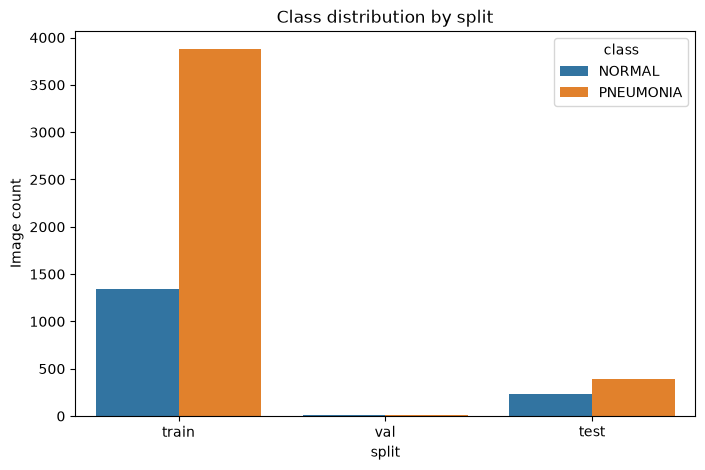

In [17]:
# 클래스 분포 시각화 — 막대그래프로 불균형 확인 (PNEUMONIA가 더 많음)

import pandas as pd

df = pd.DataFrame([
    {"split": s, "class": c, "count": counts[(s, c)]}
    for s in splits for c in classes
])

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="split", y="count", hue="class")
plt.title("Class distribution by split")
plt.ylabel("Image count")
plt.show()

ㄴ인사이트: PNEUMONIA가 train 전체의 약 74% 차지. 불균형이 시각적으로도 뚜렷함.

### 3. 샘플 이미지 확인

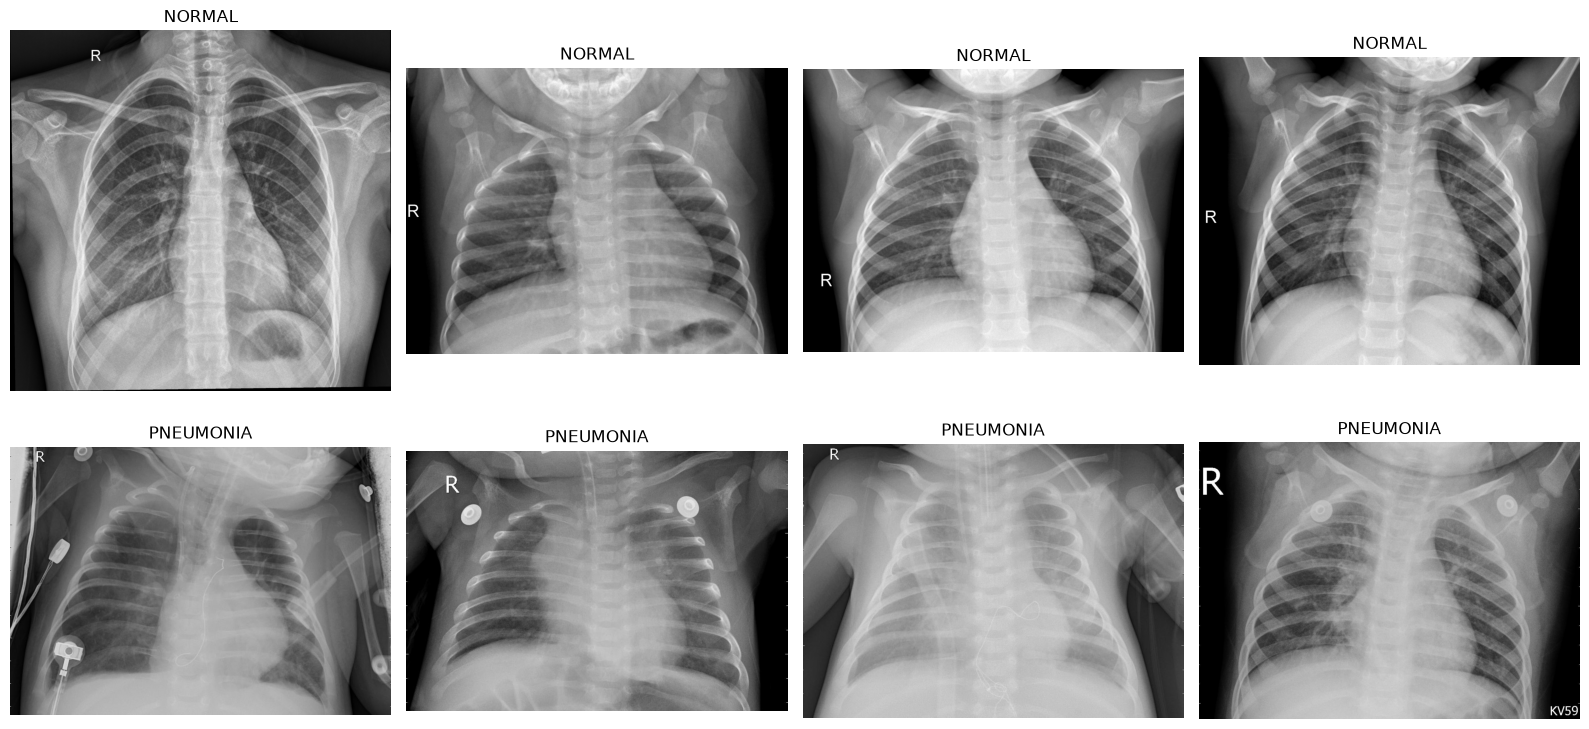

In [18]:
# 샘플 이미지 확인 — 실제 이미지 비교, PNEUMONIA에 의료장비 아티팩트 있는 거 발견

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, "train", cls)
    sample_files = os.listdir(cls_path)[:4]
    for j, fname in enumerate(sample_files):
        img = Image.open(os.path.join(cls_path, fname))
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].set_title(cls)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

ㄴ인사이트: PNEUMONIA 이미지에 튜브·패치 같은 의료장비가 자주 동반됨. 모델이 폐 병변 대신 장비 유무로 학습할 위험이 있어 한계점으로 기록.

### 4. 이미지 해상도 (크기) 범위 확인

In [19]:
# 이미지 해상도(크기) 범위 확인 — 해상도가 제각각이라 리사이즈 필요성 확인
import numpy as np

sizes = []
for split in splits:
    for cls in classes:
        cls_path = os.path.join(base_dir, split, cls)
        for fname in os.listdir(cls_path)[:50]:
            img = Image.open(os.path.join(cls_path, fname))
            sizes.append(img.size)

sizes = np.array(sizes)
print("Width range:", sizes[:,0].min(), "-", sizes[:,0].max())
print("Height range:", sizes[:,1].min(), "-", sizes[:,1].max())

Width range: 384 - 2720
Height range: 127 - 2663


ㄴ인사이트: 이미지 해상도 편차가 큼(384~2720 x 127~2663). 224x224로 통일 리사이즈 필요.

### 5. 데이터셋 재구성 (전처리)

In [20]:
# train/val 재분할(stratified) + 데이터셋 - 로딩 원본 val(16장)이 너무 작아서 train에서 15% 떼어 새로 분할, 224x224 리사이즈 전처리 정의

from torchvision import datasets, transforms
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import torch
from collections import Counter

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train_dataset = datasets.ImageFolder(os.path.join(base_dir, "train"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, "test"), transform=transform)

targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    list(range(len(targets))), test_size=0.15, stratify=targets, random_state=42
)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_train_dataset, val_idx)

print("train:", len(train_dataset), "val:", len(val_dataset), "test:", len(test_dataset))
print("클래스 매핑:", full_train_dataset.class_to_idx)

train_targets = [targets[i] for i in train_idx]
print("train 클래스 분포:", Counter(train_targets))

train: 4433 val: 783 test: 624
클래스 매핑: {'NORMAL': 0, 'PNEUMONIA': 1}
train 클래스 분포: Counter({1: 3293, 0: 1140})


ㄴ인사이트: 원본 val 대신 train에서 stratified로 15% 떼어 새 val 구성(train 4433 / val 783 / test 624).
train 내 불균형은 유지됨(NORMAL 1140 vs PNEUMONIA 3293) → 학습 시 class weight 적용 필요.

### 6. DataLoader + 디바이스 설정

In [21]:
# DataLoader 생성 + 학습 디바이스 설정 (M2는 mps, 추후 다른 기기에선 cuda/cpu로 자동 분기)
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("사용 디바이스:", device)

사용 디바이스: mps


### 7. Simple CNN 정의

In [22]:
# Simple CNN 모델 정의 - 베이스라인으로 쓸 간단한 CNN 구조 설계 (다음에 transfer learning 모델이랑 성능 비교 예정)
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

ㄴ인사이트: conv 4블록을 거치며 (Conv→BatchNorm→ReLU→MaxPool을 4번 반복) 224x224 입력이 14x14까지 줄어들고 채널은 128까지 늘어남(점점 더 복잡한 패턴 추출). 파라미터 수가 적어 학습은 빠르지만, 사전학습 정보가 없어서 transfer learning 모델보다 일반화 성능이 낮을 가능성 있음 — 다음 비교 실험에서 검증.

### 8. 클래스 불균형 보정(class weight) + 손실함수, 옵티마이저 정의

In [23]:
# 클래스 불균형 보정(class weight) + 손실함수, 옵티마이저 정의
import torch.optim as optim

class_counts = torch.tensor([1140, 3293], dtype=torch.float)  # [NORMAL, PNEUMONIA]
class_weights = class_counts.sum() / (2 * class_counts)
class_weights = class_weights.to(device)
print("클래스 가중치:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

클래스 가중치: tensor([1.9443, 0.6731], device='mps:0')


ㄴ인사이트: NORMAL에 1.94, PNEUMONIA에 0.67의 가중치가 부여됨 — 원래 클래스 비율(약 2.9:1)의 역수에 해당하는 값. 이렇게 하면 학습 중 NORMAL을 틀렸을 때 더 크게 패널티를 줘서, 모델이 다수 클래스(PNEUMONIA)로만 쏠려서 찍는 걸 방지함.

### 9. 실제 학습 루프

In [24]:
# 1 epoch 학습 함수
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [25]:
# 검증/테스트 평가 함수 (gradient 계산 없음)
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [26]:
# Simple CNN 학습 실행 (특별한 기법 없이 기본으로 돌렸을 때 결과가 이렇다는 걸 보여주는 기준점)
num_epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

Epoch 1/10 | train_loss: 0.3401 train_acc: 0.8509 | val_loss: 0.5773 val_acc: 0.8301


KeyboardInterrupt: 

ㄴ인사이트: train_acc는 85% → 95%로 꾸준히 상승하는데, val_acc는 epoch 4(95%)에서 peak 찍고 이후 하락(87%). train loss는 계속 줄고 val loss는 들쭉날쭉한 것도 같은 신호야 — 이게 전형적인 과적합(overfitting) 패턴이야.
-> 즉, 모델이 문제집 답을 외워버려서 모의고사에서 실력 발휘를 못 하는 상태. 이게 Simple CNN의 한계이고, 다음에 할 transfer learning과 비교할 핵심 포인트가 돼.




### 9. Simple CNN 학습 곡선 시각화 - train vs val 성능 비교로 과적합 여부 확인

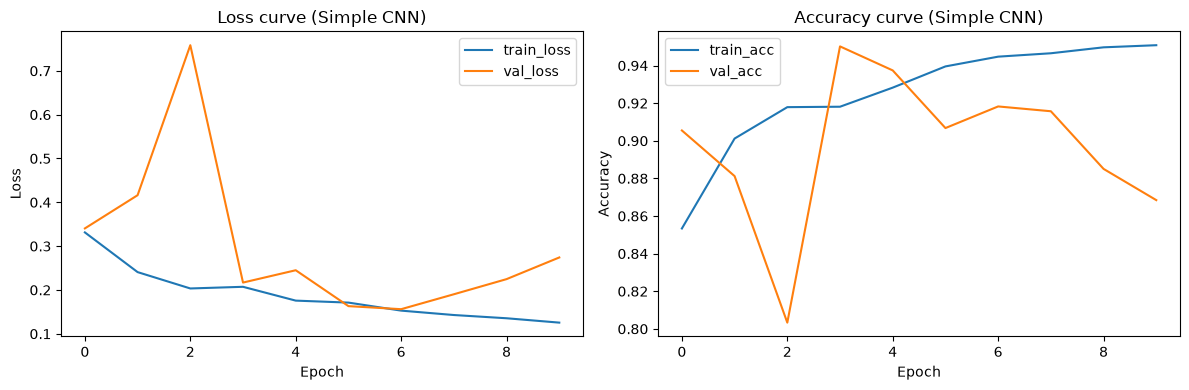

In [ ]:
# 학습 곡선 시각화 - train vs val 성능 비교로 과적합 여부 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss 그래프
axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss curve (Simple CNN)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy 그래프
axes[1].plot(history["train_acc"], label="train_acc")
axes[1].plot(history["val_acc"], label="val_acc")
axes[1].set_title("Accuracy curve (Simple CNN)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

ㄴ인사이트: Loss 그래프에서 train_loss는 꾸준히 감소하는데 val_loss는 epoch 2~3에서 0.75까지 튀어오르고 불안정하게 출렁임. Accuracy 그래프도 train_acc는 우상향하는데 val_acc는 epoch 2~3에서 80%까지 떨어지고 이후에도 들쭉날쭉. 이게 전형적인 과적합 신호 — Simple CNN이 train 데이터를 외워버리기 시작한 거야. Transfer Learning으로 이 문제가 얼마나 개선되는지가 다음 비교 포인트야.

### 10. EfficientNetB0 정의 셀

In [32]:
# Transfer Learning 모델 정의 - 로컬에 저장된 가중치 직접 로드
from torchvision import models
import torch

efficientnet = models.efficientnet_b0(weights=None)  # 인터넷 다운 안 함
efficientnet.load_state_dict(torch.load("efficientnet_b0.pth", map_location=device))

# 마지막 분류층을 2클래스(NORMAL/PNEUMONIA)용으로 교체
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(in_features, 2)
efficientnet = efficientnet.to(device)

optimizer_eff = optim.Adam(efficientnet.parameters(), lr=1e-4)
print("EfficientNetB0 마지막 레이어:", efficientnet.classifier)

EfficientNetB0 마지막 레이어: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


ㄴ인사이트: ImageNet으로 사전학습된 EfficientNetB0의 특징 추출 레이어는 그대로 유지하고, 마지막 분류층(in_features=1280)만 2클래스용으로 교체. lr을 Simple CNN(1e-3)보다 작은 1e-4로 설정해 기존 가중치가 너무 크게 변하지 않도록 조정.

### 11. EfficientNetB0 학습 실행

In [33]:
# EfficientNetB0 학습 실행 - Simple CNN과 동일한 조건으로 비교
history_eff = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(efficientnet, train_loader, criterion, optimizer_eff, device)
    val_loss, val_acc = evaluate(efficientnet, val_loader, criterion, device)

    history_eff["train_loss"].append(train_loss)
    history_eff["train_acc"].append(train_acc)
    history_eff["val_loss"].append(val_loss)
    history_eff["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

Epoch 1/10 | train_loss: 0.1893 train_acc: 0.9294 | val_loss: 0.0776 val_acc: 0.9655
Epoch 2/10 | train_loss: 0.0583 train_acc: 0.9815 | val_loss: 0.0446 val_acc: 0.9834
Epoch 3/10 | train_loss: 0.0267 train_acc: 0.9923 | val_loss: 0.0323 val_acc: 0.9898
Epoch 4/10 | train_loss: 0.0156 train_acc: 0.9957 | val_loss: 0.0422 val_acc: 0.9796
Epoch 5/10 | train_loss: 0.0113 train_acc: 0.9966 | val_loss: 0.0260 val_acc: 0.9911
Epoch 6/10 | train_loss: 0.0230 train_acc: 0.9923 | val_loss: 0.0294 val_acc: 0.9898
Epoch 7/10 | train_loss: 0.0087 train_acc: 0.9977 | val_loss: 0.0234 val_acc: 0.9898
Epoch 8/10 | train_loss: 0.0104 train_acc: 0.9973 | val_loss: 0.0266 val_acc: 0.9898
Epoch 9/10 | train_loss: 0.0092 train_acc: 0.9973 | val_loss: 0.0280 val_acc: 0.9885
Epoch 10/10 | train_loss: 0.0055 train_acc: 0.9984 | val_loss: 0.0501 val_acc: 0.9898


ㄴ인사이트: EfficientNetB0은 epoch 1부터 val_acc 96.5%로 시작해 epoch 5에서 99.1%까지 도달. Simple CNN의 최고치(95%)를 epoch 1에서 이미 넘어섬. val_loss도 0.02~0.05 사이로 안정적 — 사전학습 가중치 덕분에 과적합 없이 빠르게 수렴한 것. 의료 영상처럼 데이터가 제한적인 환경에서 Transfer Learning이 훨씬 효과적임을 확인.



### 12. EfficientNetB0 학습 곡선 시각화 - train vs val 성능으로 과적합 여부 확인

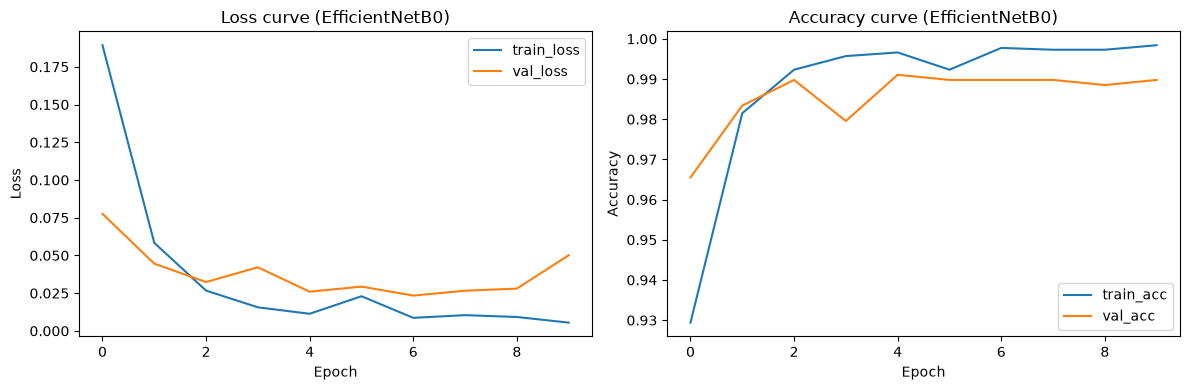

In [34]:
# EfficientNetB0 학습 곡선 시각화 - Simple CNN과 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_eff["train_loss"], label="train_loss")
axes[0].plot(history_eff["val_loss"], label="val_loss")
axes[0].set_title("Loss curve (EfficientNetB0)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_eff["train_acc"], label="train_acc")
axes[1].plot(history_eff["val_acc"], label="val_acc")
axes[1].set_title("Accuracy curve (EfficientNetB0)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

ㄴ인사이트: Loss 그래프에서 train_loss와 val_loss가 함께 빠르게 수렴하며 간격이 거의 없음 — Simple CNN에서 보였던 과적합 패턴이 사라짐. Accuracy 그래프도 두 선이 epoch 2부터 98~99%대에서 나란히 유지됨. Transfer Learning이 일반화 성능과 학습 안정성 모두에서 Simple CNN을 압도한다는 것을 시각적으로 확인.

### 13. 두 모델 val 성능 직접 비교 - y축 고정으로 Simple CNN vs EfficientNetB0 차이 명확화

/var/folders/bm/1f717f9n3cl3vvz7_p6ncg_80000gn/T/ipykernel_69062/1427592368.py:20: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bm/1f717f9n3cl3vvz7_p6ncg_80000gn/T/ipykernel_69062/1427592368.py:20: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


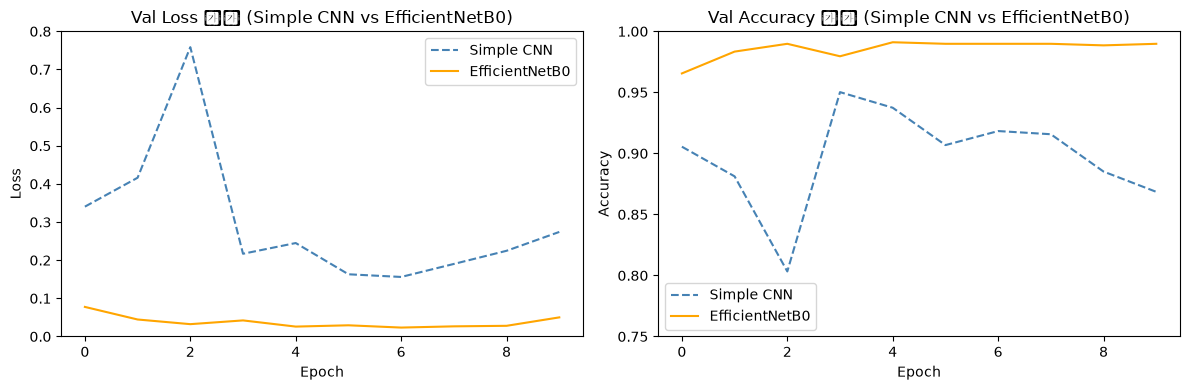

In [42]:
# 두 모델 val 성능 비교 시각화 - y축 범위 고정으로 차이 명확히 표현
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["val_loss"], label="Simple CNN", linestyle="--", color="steelblue")
axes[0].plot(history_eff["val_loss"], label="EfficientNetB0", color="orange")
axes[0].set_title("Val Loss 비교 (Simple CNN vs EfficientNetB0)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(0, 0.8)
axes[0].legend()

axes[1].plot(history["val_acc"], label="Simple CNN", linestyle="--", color="steelblue")
axes[1].plot(history_eff["val_acc"], label="EfficientNetB0", color="orange")
axes[1].set_title("Val Accuracy 비교 (Simple CNN vs EfficientNetB0)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.75, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()


ㄴ인사이트: Simple CNN(파란 점선)은 val_loss가 epoch 2~3에서 0.75까지 치솟고 val_acc도 80%까지 떨어지는 불안정한 패턴. EfficientNetB0(주황 실선)는 epoch 1부터 97% 이상을 유지하며 거의 흔들림 없이 수렴. 두 모델의 성능 격차가 시각적으로 명확히 드러나며, 사전학습 기반 Transfer Learning의 우월성을 확인.

In [40]:
print(history["val_acc"])
print(history["val_loss"])

[0.8301404853128991]
[0.5773250076201379]


In [41]:
# Simple CNN history 수동 복원 - 이전 학습 결과값 직접 입력
history = {
    "train_loss": [0.3313, 0.2407, 0.2034, 0.2072, 0.1757, 0.1711, 0.1528, 0.1428, 0.1354, 0.1255],
    "train_acc": [0.8534, 0.9012, 0.9179, 0.9181, 0.9283, 0.9395, 0.9447, 0.9465, 0.9497, 0.9508],
    "val_loss": [0.3404, 0.4162, 0.7585, 0.2169, 0.2450, 0.1631, 0.1561, 0.1902, 0.2247, 0.2741],
    "val_acc": [0.9055, 0.8812, 0.8033, 0.9502, 0.9374, 0.9068, 0.9183, 0.9157, 0.8851, 0.8685]
}
print("history 복원 완료")

history 복원 완료


### 14. 테스트셋 최종 성능 평가

In [43]:
# 테스트셋 최종 평가 - 학습에 한 번도 사용하지 않은 데이터로 최종 성능 측정
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Simple CNN 테스트
cnn_labels, cnn_preds = get_predictions(model, test_loader, device)
print("=== Simple CNN ===")
print(classification_report(cnn_labels, cnn_preds, target_names=["NORMAL", "PNEUMONIA"]))

# EfficientNetB0 테스트
eff_labels, eff_preds = get_predictions(efficientnet, test_loader, device)
print("=== EfficientNetB0 ===")
print(classification_report(eff_labels, eff_preds, target_names=["NORMAL", "PNEUMONIA"]))

=== Simple CNN ===
              precision    recall  f1-score   support

      NORMAL       0.89      0.37      0.52       234
   PNEUMONIA       0.72      0.97      0.83       390

    accuracy                           0.75       624
   macro avg       0.80      0.67      0.67       624
weighted avg       0.78      0.75      0.71       624

=== EfficientNetB0 ===
              precision    recall  f1-score   support

      NORMAL       0.98      0.56      0.71       234
   PNEUMONIA       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624



ㄴ인사이트: val에서 99%였던 EfficientNetB0가 test에서 83%로 떨어진 건 test셋 분포가 다르기 때문. 두 모델 공통적으로 NORMAL recall이 낮아(CNN 37%, EfficientNet 56%) — 모델이 PNEUMONIA로 쏠려서 찍는 경향이 남아있음. 의료 관점에서 NORMAL을 PNEUMONIA로 잘못 분류하는 것(False Positive)보다, PNEUMONIA를 NORMAL로 놓치는 것(False Negative)이 더 위험한데, PNEUMONIA recall은 둘 다 97~99%로 높아 이 부분은 양호함.

### 15. Confusion Matrix 시각화

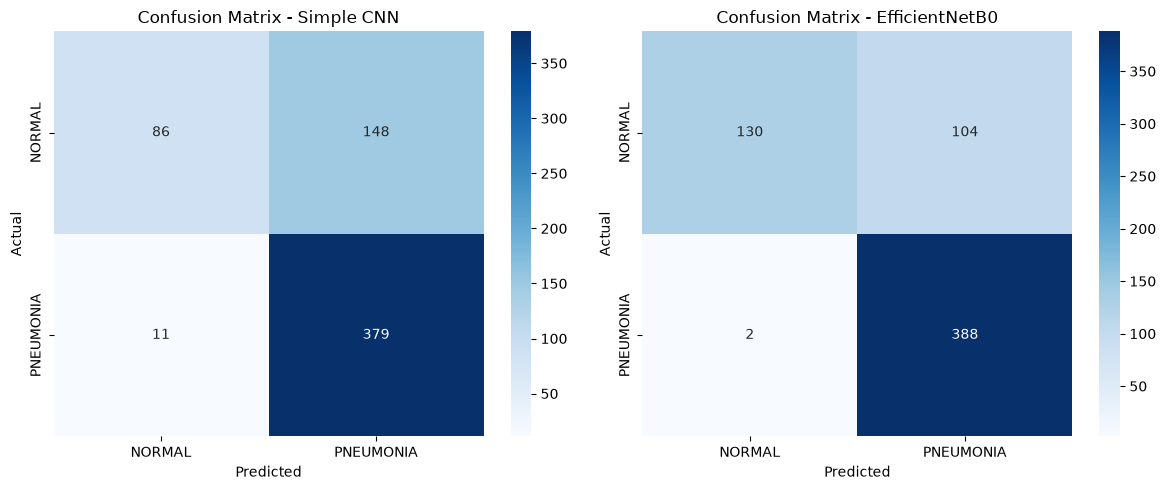

In [44]:
# Confusion Matrix 시각화 - 두 모델의 오분류 패턴 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, preds, title in zip(
    axes,
    [cnn_labels, eff_labels],
    [cnn_preds, eff_preds],
    ["Simple CNN", "EfficientNetB0"]
):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    ax.set_title(f"Confusion Matrix - {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

ㄴ인사이트: Simple CNN은 실제 NORMAL 234장 중 148장을 PNEUMONIA로 오분류(False Positive 63%) — NORMAL을 제대로 못 잡는 심각한 편향이 있음. EfficientNetB0는 같은 상황에서 104장 오분류(44%)로 개선됐지만 여전히 높음. 반면 실제 PNEUMONIA를 NORMAL로 놓치는 경우(False Negative)는 CNN 11장, EfficientNetB0 2장으로 EfficientNetB0가 압도적으로 우수. 의료 스크리닝 관점에서 폐렴 환자를 놓치지 않는 것이 최우선인데, 이 부분에서 EfficientNetB0(FN=2)가 훨씬 안전한 모델임.

### 16. GradCAM 클래스 정의 - 모델이 어디를 보고 판단했는지 히트맵으로 시각화

In [46]:
# Grad-CAM 클래스 정의 - 모델이 이미지의 어느 부분에 집중해서 판단했는지 히트맵으로 시각화
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)  # forward 시 활성화값 저장
        target_layer.register_full_backward_hook(self.save_gradient)  # backward 시 기울기 저장

    def save_activation(self, module, input, output):
        self.activations = output.detach()  # 해당 레이어의 특징맵 저장

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()  # 해당 레이어로 흘러간 기울기 저장

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)  # 예측 수행
        self.model.zero_grad()
        output[0, class_idx].backward()  # 관심 클래스(class_idx) 기준으로 역전파

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # 채널별 중요도 계산
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # 가중합으로 히트맵 생성
        cam = F.relu(cam)  # 양의 기여도만 남김
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)  # 원본 이미지 크기로 확대
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # 0~1로 정규화
        return cam

# EfficientNetB0의 마지막 conv 레이어를 target으로 지정 (가장 깊은 특징을 담고 있는 레이어)
target_layer = efficientnet.features[-1]
gradcam = GradCAM(efficientnet, target_layer)
print("GradCAM 준비 완료")

GradCAM 준비 완료


### 17. Grad-CAM 시각화 - test셋 샘플 이미지에 히트맵 오버레이 

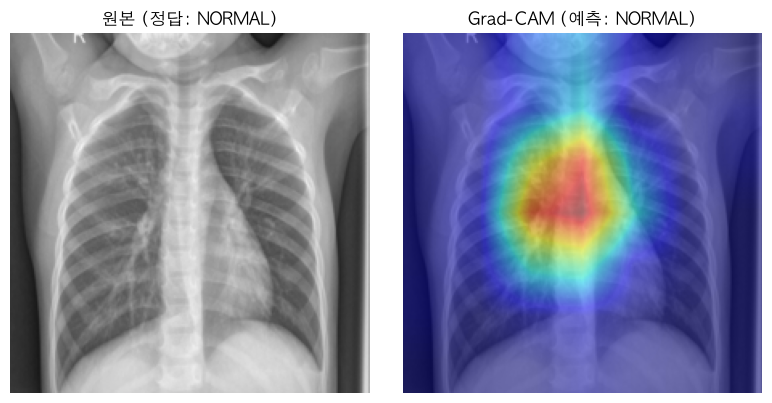

In [49]:
# Grad-CAM 시각화 - test셋 샘플 이미지에 히트맵 오버레이
import matplotlib.cm as cm

def show_gradcam(model, gradcam, dataset, idx, class_names, device):
    img_tensor, label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    cam = gradcam.generate(input_tensor, pred_class)

    # 정규화 되돌리기 (원본 이미지처럼 보이게)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"원본 (정답: {class_names[label]})")
    axes[0].axis("off")

    axes[1].imshow(img)
    axes[1].imshow(cam, cmap="jet", alpha=0.5)
    axes[1].set_title(f"Grad-CAM (예측: {class_names[pred_class]})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

class_names = ["NORMAL", "PNEUMONIA"]
# PNEUMONIA로 예측된 샘플 하나 확인
show_gradcam(efficientnet, gradcam, test_dataset, 5, class_names, device)

ㄴ인사이트: NORMAL로 정확히 예측된 케이스인데, Grad-CAM 히트맵이 폐 영역 가장자리가 아니라 흉부 중앙(심장/종격동 부근)에 집중되어 있음. 이는 모델이 폐 음영의 미세한 패턴보다는 흉곽의 전반적인 형태나 중심부 구조를 기준으로 NORMAL을 판단했을 가능성을 시사 — 임상적으로 의미 있는 폐 영역 자체를 보고 있는지는 추가 샘플로 더 확인이 필요한 한계점.

In [48]:
# 18. 한글 폰트 설정 - matplotlib 그래프에서 한글 깨짐 방지
import matplotlib.font_manager as fm
import platform

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
print("폰트 설정 완료")

폰트 설정 완료


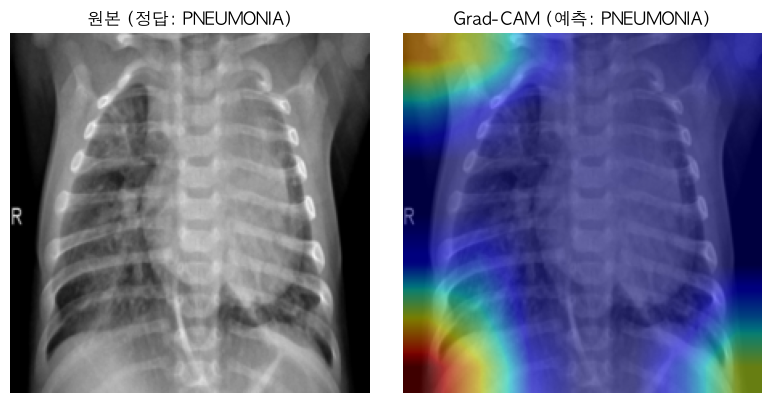

In [50]:
# 18. Grad-CAM 시각화 - PNEUMONIA 샘플로 추가 확인
pneumonia_idx = next(i for i, (_, label) in enumerate(test_dataset) if label == 1)
show_gradcam(efficientnet, gradcam, test_dataset, pneumonia_idx, class_names, device)

ㄴ인사이트: PNEUMONIA로 정확히 예측된 케이스에서, Grad-CAM 히트맵이 양쪽 폐 하단부(아래쪽 가장자리)에 집중됨. 폐렴이 실제로 폐 하엽에 자주 발생한다는 점과 일치해, 모델이 임상적으로 의미 있는 부위를 근거로 판단했을 가능성을 보여줌. 다만 이미지 가장자리(흉곽 외곽)까지 일부 포함된 점은, 폐 조직 자체가 아니라 신체 윤곽 같은 무관한 특징도 같이 참고했을 가능성이 있어 추가 샘플 확인이 필요한 한계점.

[한계점 (Limitations)]

1. 클래스 불균형: train 데이터에서 PNEUMONIA가 NORMAL보다 약 2.9배 많아 class weight로 보정했지만, test셋에서도 NORMAL recall이 낮게 나오는(CNN 37%, EfficientNetB0 56%) 근본적인 영향이 남아있음
2. 의료장비 아티팩트: PNEUMONIA 이미지에 튜브·패치 등 의료장비가 자주 동반되어, 모델이 병변이 아닌 장비 유무로 학습했을 가능성 존재
3. 작은 원본 val셋: 원본 데이터셋의 val이 16장뿐이라 train에서 별도로 떼어 재구성함 — 데이터셋 자체의 알려진 한계
4. Grad-CAM 해석의 일관성 부족: 일부 케이스(NORMAL)에서 모델이 폐 영역이 아닌 심장 부근에 집중하는 경향이 관찰됨 — 항상 임상적으로 의미 있는 부위를 보는 것은 아님
5. 소아 환자 데이터에 한정: 원본 데이터가 1~5세 소아 환자 대상이라, 성인 X-ray에 그대로 일반화하기는 어려움